In [ ]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
uploaded = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv


In [ ]:
csv_filename = next(
    name for name in uploaded
    if name.lower().endswith(".csv")
)

print("Uploaded file:", csv_filename)

Uploaded file: ObesityDataSet_raw_and_data_sinthetic.csv


In [ ]:
df = pd.read_csv(csv_filename)

print("Dataset loaded.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded.
Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:")
print(df.duplicated().sum())

print("\nTarget classes:")
print(df["NObeyesdad"].value_counts())

Column names:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Exact duplicate rows:
24

Target classes:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweigh

In [ ]:
original_rows = len(df)
duplicate_count = int(df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

cleaned_rows = len(df)

print("Original rows:", original_rows)
print("Duplicates removed:", duplicate_count)
print("Cleaned rows:", cleaned_rows)

Original rows: 2111
Duplicates removed: 24
Cleaned rows: 2087


In [ ]:
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2087, 16)
y shape: (2087,)


In [ ]:
RANDOM_SEED = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (1460, 16) (1460,)
Validation: (313, 16) (313,)
Test: (314, 16) (314,)


In [ ]:
print("TRAINING CLASSES")
print(y_train.value_counts())

print("\nVALIDATION CLASSES")
print(y_val.value_counts())

print("\nTEST CLASSES")
print(y_test.value_counts())

TRAINING CLASSES
NObeyesdad
Obesity_Type_I         245
Obesity_Type_III       227
Obesity_Type_II        208
Overweight_Level_II    203
Normal_Weight          197
Overweight_Level_I     193
Insufficient_Weight    187
Name: count, dtype: int64

VALIDATION CLASSES
NObeyesdad
Obesity_Type_I         53
Obesity_Type_III       48
Obesity_Type_II        44
Normal_Weight          43
Overweight_Level_II    43
Overweight_Level_I     42
Insufficient_Weight    40
Name: count, dtype: int64

TEST CLASSES
NObeyesdad
Obesity_Type_I         53
Obesity_Type_III       49
Obesity_Type_II        45
Overweight_Level_II    44
Normal_Weight          42
Overweight_Level_I     41
Insufficient_Weight    40
Name: count, dtype: int64


In [ ]:
def create_preprocessor(dataframe):

    numeric_columns = dataframe.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_pipeline = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        ]
    )

    return preprocessor

In [ ]:
full_preprocessor = create_preprocessor(X_train)

print("Preprocessor created.")

Preprocessor created.


In [ ]:
candidate_models = {
    "Dummy": [
        (
            "most_frequent",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ],

    "Logistic Regression": [
        (
            "C=0.1",
            LogisticRegression(
                C=0.1,
                max_iter=2000
            )
        ),
        (
            "C=1",
            LogisticRegression(
                C=1.0,
                max_iter=2000
            )
        ),
        (
            "C=10",
            LogisticRegression(
                C=10.0,
                max_iter=2000
            )
        )
    ],

    "Decision Tree": [
        (
            "depth=5",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=5,
                random_state=RANDOM_SEED
            )
        ),
        (
            "depth=10",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=5,
                random_state=RANDOM_SEED
            )
        ),
        (
            "depth=None",
            DecisionTreeClassifier(
                max_depth=None,
                min_samples_leaf=5,
                random_state=RANDOM_SEED
            )
        )
    ],

    "Random Forest": [
        (
            "trees=100",
            RandomForestClassifier(
                n_estimators=100,
                min_samples_leaf=2,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
        ),
        (
            "trees=300",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
        ),
        (
            "trees=500",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
        )
    ],

    "Gradient Boosting": [
        (
            "estimators=100",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_SEED
            )
        ),
        (
            "estimators=300",
            GradientBoostingClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_SEED
            )
        ),
        (
            "estimators=500",
            GradientBoostingClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_SEED
            )
        )
    ]
}

In [ ]:
validation_results = []

selected_estimators = {}
selected_setting_names = {}

for model_name, candidates in candidate_models.items():

    best_macro_f1 = -1
    best_estimator = None
    best_setting_name = None

    for setting_name, estimator in candidates:

        model_pipeline = Pipeline(steps=[
            (
                "preprocessor",
                clone(full_preprocessor)
            ),
            (
                "classifier",
                clone(estimator)
            )
        ])

        model_pipeline.fit(
            X_train,
            y_train
        )

        predictions = model_pipeline.predict(
            X_val
        )

        macro_f1 = f1_score(
            y_val,
            predictions,
            average="macro",
            zero_division=0
        )

        accuracy = accuracy_score(
            y_val,
            predictions
        )

        precision = precision_score(
            y_val,
            predictions,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_val,
            predictions,
            average="macro",
            zero_division=0
        )

        validation_results.append({
            "Model": model_name,
            "Setting": setting_name,
            "Macro-F1": macro_f1,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall
        })

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_estimator = clone(estimator)
            best_setting_name = setting_name

    selected_estimators[model_name] = best_estimator
    selected_setting_names[model_name] = best_setting_name


validation_results_df = pd.DataFrame(
    validation_results
)

display(
    validation_results_df
    .sort_values(
        ["Model", "Macro-F1"],
        ascending=[True, False]
    )
    .round(4)
)

,Model,Setting,Macro-F1,Accuracy,Precision,Recall
5,Decision Tree,depth=10,0.9306,0.9329,0.9315,0.9306
6,Decision Tree,depth=None,0.9306,0.9329,0.9335,0.9304
4,Decision Tree,depth=5,0.7952,0.8051,0.8186,0.7953
0,Dummy,most_frequent,0.0414,0.1693,0.0242,0.1429
11,Gradient Boosting,estimators=300,0.9531,0.9553,0.9548,0.9529
12,Gradient Boosting,estimators=500,0.9531,0.9553,0.9544,0.9531
10,Gradient Boosting,estimators=100,0.9237,0.9265,0.9264,0.9235
3,Logistic Regression,C=10,0.9428,0.9425,0.9432,0.9428
2,Logistic Regression,C=1,0.8954,0.8978,0.8960,0.8964
1,Logistic Regression,C=0.1,0.7833,0.7923,0.7831,0.7908


In [ ]:
selected_settings_df = pd.DataFrame([
    {
        "Model": model_name,
        "Selected Setting": setting_name
    }
    for model_name, setting_name
    in selected_setting_names.items()
])

display(selected_settings_df)

,Model,Selected Setting
0,Dummy,most_frequent
1,Logistic Regression,C=10
2,Decision Tree,depth=10
3,Random Forest,trees=300
4,Gradient Boosting,estimators=300


In [ ]:
FROZEN_MODELS = {
    model_name: clone(estimator)
    for model_name, estimator
    in selected_estimators.items()
}

print("Model settings are now frozen.")

for model_name, setting_name in selected_setting_names.items():
    print(model_name, "→", setting_name)

Model settings are now frozen.
Dummy → most_frequent
Logistic Regression → C=10
Decision Tree → depth=10
Random Forest → trees=300
Gradient Boosting → estimators=300


In [ ]:
X_development = pd.concat(
    [X_train, X_val],
    axis=0
)

y_development = pd.concat(
    [y_train, y_val],
    axis=0
)

print("Development:", X_development.shape)
print("Final test:", X_test.shape)

Development: (1773, 16)
Final test: (314, 16)


In [ ]:
def evaluate_condition(
    condition_name,
    X_development_condition,
    X_test_condition,
    frozen_models,
    output_folder
):

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    preprocessor = create_preprocessor(
        X_development_condition
    )

    results = []
    trained_models = {}

    for model_name, estimator in frozen_models.items():

        pipeline = Pipeline(steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                clone(estimator)
            )
        ])

        start_time = time.perf_counter()

        pipeline.fit(
            X_development_condition,
            y_development
        )

        training_time = (
            time.perf_counter()
            - start_time
        )

        predictions = pipeline.predict(
            X_test_condition
        )

        probabilities = pipeline.predict_proba(
            X_test_condition
        )

        class_order = (
            pipeline
            .named_steps["classifier"]
            .classes_
        )

        macro_f1 = f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        macro_precision = precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )

        macro_auc = roc_auc_score(
            y_test,
            probabilities,
            labels=class_order,
            multi_class="ovr",
            average="macro"
        )




        safe_name = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        model_path = os.path.join(
            output_folder,
            f"{safe_name}.joblib"
        )

        joblib.dump(
            pipeline,
            model_path
        )

        model_size_mb = (
            os.path.getsize(model_path)
            / (1024 ** 2)
        )

        results.append({
            "Condition": condition_name,
            "Model": model_name,
            "Macro-F1": macro_f1,
            "Accuracy": accuracy,
            "Precision (macro)": macro_precision,
            "Recall (macro)": macro_recall,
            "AUC (macro OvR)": macro_auc,

            "Training Time (s)": training_time,
            "Model Size (MB)": model_size_mb
        })

        trained_models[model_name] = pipeline

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "Macro-F1",
        ascending=False
    ).reset_index(drop=True)

    return results_df, trained_models

In [ ]:
full_results_df, full_trained_models = evaluate_condition(
    condition_name="Full Features",
    X_development_condition=X_development,
    X_test_condition=X_test,
    frozen_models=FROZEN_MODELS,
    output_folder="models_full"
)

display(
    full_results_df.round(4)
)

full_results_df.to_csv(
    "full_results_all_metrics.csv",
    index=False
)

,Condition,Model,Macro-F1,Accuracy,Precision (macro),Recall (macro),AUC (macro OvR),Training Time (s),Model Size (MB)
0,Full Features,Gradient Boosting,0.9845,0.9841,0.9843,0.9853,0.9994,11.7836,2.5465
1,Full Features,Logistic Regression,0.9363,0.9395,0.9372,0.9363,0.9956,0.6247,0.0079
2,Full Features,Random Forest,0.9349,0.9363,0.9393,0.9337,0.9941,2.7265,12.8830
3,Full Features,Decision Tree,0.9334,0.9363,0.9342,0.9340,0.9875,0.0866,0.0228
4,Full Features,Dummy,0.0413,0.1688,0.0241,0.1429,0.5000,0.0239,0.0060


In [ ]:
X_development_no_hw = X_development.drop(
    columns=["Height", "Weight"]
)

X_test_no_hw = X_test.drop(
    columns=["Height", "Weight"]
)

print("Full development:", X_development.shape)
print("Without H/W development:", X_development_no_hw.shape)

print("Full test:", X_test.shape)
print("Without H/W test:", X_test_no_hw.shape)

Full development: (1773, 16)
Without H/W development: (1773, 14)
Full test: (314, 16)
Without H/W test: (314, 14)


In [ ]:
ablation_results_df, ablation_trained_models = evaluate_condition(
    condition_name="Without Height and Weight",
    X_development_condition=X_development_no_hw,
    X_test_condition=X_test_no_hw,
    frozen_models=FROZEN_MODELS,
    output_folder="models_without_height_weight"
)

display(
    ablation_results_df.round(4)
)

ablation_results_df.to_csv(
    "ablation_results_all_metrics.csv",
    index=False
)

,Condition,Model,Macro-F1,Accuracy,Precision (macro),Recall (macro),AUC (macro OvR),Training Time (s),Model Size (MB)
0,Without Height and Weight,Gradient Boosting,0.8562,0.8567,0.8612,0.8547,0.9693,8.6302,2.5721
1,Without Height and Weight,Random Forest,0.8267,0.8312,0.8266,0.8285,0.9766,0.6946,15.1175
2,Without Height and Weight,Decision Tree,0.6758,0.6879,0.6815,0.6794,0.8936,0.0469,0.0371
3,Without Height and Weight,Logistic Regression,0.6123,0.6369,0.6363,0.6278,0.8966,0.2053,0.0077
4,Without Height and Weight,Dummy,0.0413,0.1688,0.0241,0.1429,0.5000,0.0154,0.0059


In [ ]:
metric_columns = [
    "Macro-F1",
    "Accuracy",
    "Precision (macro)",
    "Recall (macro)",
    "AUC (macro OvR)",

]

full_compare = full_results_df[
    ["Model"] + metric_columns
].copy()

full_compare = full_compare.rename(
    columns={
        metric: f"Full {metric}"
        for metric in metric_columns
    }
)

ablation_compare = ablation_results_df[
    ["Model"] + metric_columns
].copy()

ablation_compare = ablation_compare.rename(
    columns={
        metric: f"No H/W {metric}"
        for metric in metric_columns
    }
)

comparison_df = full_compare.merge(
    ablation_compare,
    on="Model"
)

for metric in metric_columns:
    comparison_df[
        f"Delta {metric}"
    ] = (
        comparison_df[f"No H/W {metric}"]
        - comparison_df[f"Full {metric}"]
    )

comparison_df = comparison_df.sort_values(
    "Full Macro-F1",
    ascending=False
).reset_index(drop=True)

display(
    comparison_df.round(4)
)

comparison_df.to_csv(
    "comparison_all_metrics.csv",
    index=False
)

,Model,Full Macro-F1,Full Accuracy,Full Precision (macro),Full Recall (macro),Full AUC (macro OvR),No H/W Macro-F1,No H/W Accuracy,No H/W Precision (macro),No H/W Recall (macro),No H/W AUC (macro OvR),Delta Macro-F1,Delta Accuracy,Delta Precision (macro),Delta Recall (macro),Delta AUC (macro OvR)
0,Gradient Boosting,0.9845,0.9841,0.9843,0.9853,0.9994,0.8562,0.8567,0.8612,0.8547,0.9693,-0.1283,-0.1274,-0.1231,-0.1306,-0.0301
1,Logistic Regression,0.9363,0.9395,0.9372,0.9363,0.9956,0.6123,0.6369,0.6363,0.6278,0.8966,-0.3240,-0.3025,-0.3009,-0.3085,-0.0990
2,Random Forest,0.9349,0.9363,0.9393,0.9337,0.9941,0.8267,0.8312,0.8266,0.8285,0.9766,-0.1082,-0.1051,-0.1126,-0.1052,-0.0175
3,Decision Tree,0.9334,0.9363,0.9342,0.9340,0.9875,0.6758,0.6879,0.6815,0.6794,0.8936,-0.2575,-0.2484,-0.2528,-0.2546,-0.0938
4,Dummy,0.0413,0.1688,0.0241,0.1429,0.5000,0.0413,0.1688,0.0241,0.1429,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


In [ ]:
winner_name = "Gradient Boosting"

full_predictions = (
    full_trained_models[winner_name]
    .predict(X_test)
)

ablation_predictions = (
    ablation_trained_models[winner_name]
    .predict(X_test_no_hw)
)

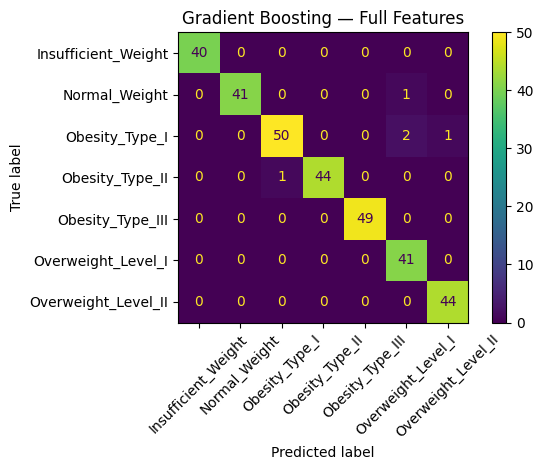

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    full_predictions,
    xticks_rotation=45
)

plt.title(
    "Gradient Boosting — Full Features"
)

plt.tight_layout()
plt.show()

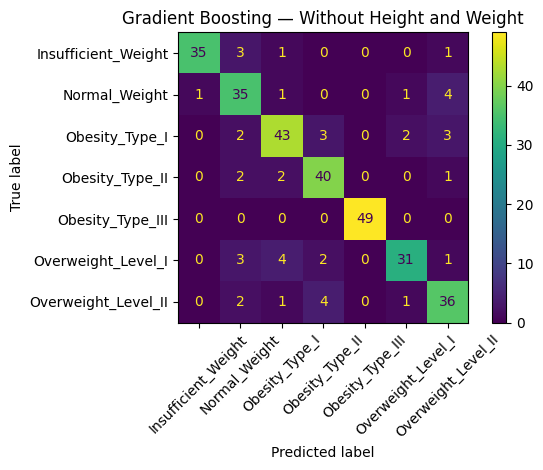

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    ablation_predictions,
    xticks_rotation=45
)

plt.title(
    "Gradient Boosting — Without Height and Weight"
)

plt.tight_layout()
plt.show()

In [ ]:
importance = permutation_importance(
    full_trained_models["Gradient Boosting"],
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean,
    "Std": importance.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.round(4)
)

,Feature,Importance,Std
0,Weight,0.7594,0.0229
1,Height,0.2901,0.0227
2,Gender,0.1471,0.0176
3,NCP,0.0142,0.0018
4,FAVC,0.0134,0.0031
5,CH2O,0.0133,0.0035
6,Age,0.0110,0.0062
7,CAEC,0.0108,0.0050
8,TUE,0.0106,0.0034
9,FCVC,0.0079,0.0037


In [ ]:
files.download(
    "full_results_all_metrics.csv"
)

files.download(
    "ablation_results_all_metrics.csv"
)

files.download(
    "comparison_all_metrics.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>